# Chess Insights: Deeper Analysis — Result Predictors and Play Sequences by Player Ranking

**Dataset:** Lichess Standard Rated Games — February 2026 (same sample as `chess_mining_pipeline.ipynb`)
**Builds on:** `chess_mining_pipeline.ipynb`, which handles ingestion, cleaning, feature engineering, descriptive statistics, chi-squared tests, and a first pass at opening-move association rules and classification. None of that is repeated here — this notebook picks up where the progress report's *Milestones Remaining* section leaves off and goes after the deeper questions the proposal actually asks:

- Does a move sequence that looks strong overall hold up anywhere in the game (not just the opening), and once you split by rating level?
- Which move sequences, anywhere in the game, are distinctly associated with *each* outcome (white win / black win / draw), not just outcomes in general?
- Once features are properly separated by *when* they're known, does anything beyond rating difference add real predictive value?

## Section Overview

*Section numbers below have a couple of intentional gaps (no 1, no 4) left over from consolidating earlier sections into others -- not renumbered yet since that would mean touching every cross-reference in the recap text below.*

| Section | Question | Method |
|---|---|---|
| 0 | Setup | Load the processed tables the pipeline already built, deep-reparse the full games |
| 2 | Does a combined, interleaved sequence of both sides' moves predict who wins, or that a game ends in a draw — anywhere in the game, not just the opening? | Contiguous move-sequence (n-gram) mining on the full game, one-vs-rest per outcome |
| 3 | Do those combined-sequence patterns hold up the same way at every rating level? | Section 2's method, repeated within each rating bin |
| 5 | How well can outcome be predicted from *only* information known before the first move is played -- including which color you're playing? | Random Forest + Logistic Regression, pre-game features only, one row per player |
| 6 | Does prediction improve once in-game information becomes available, and does it keep improving the more of the game that's been played? | Random Forest + Logistic Regression on a checkpoint panel (every 10 plies) with deduplicated pattern-timing flags |
| 7 | Model comparison | Compare Section 5 (fixed pre-game) vs. Section 6 (checkpoint panel), sliced by how much of the game has been observed |
| 8 | Synthesis | Tie findings back to the proposal's research questions |

**A data-leakage note carried over from the progress report:** the preliminary classification model in the pipeline notebook used `num_plies` as a feature for predicting `white_wins`, but `num_plies` (how many moves the game lasted) is only known *after* the game ends — it can't be part of a legitimate pre-game prediction. That mistake is exactly what motivated the report's plan to split modeling into a pre-game model and a pattern-detected model, and Sections 5-6 below fix it: Section 5 uses only features known before the first move, and Section 6 adds only information available at an early checkpoint before the game concludes, never the final move count.

---
## Section 0: Setup

Loads the tables `chess_mining_pipeline.ipynb` already produced (`games_featured.parquet`), plus a fresh deep re-parse of the same games (same `N_SAMPLE`, same file order, so `game_id` lines up) to get move sequences beyond the opening `K_MOVES` plies that pipeline notebook saved.

In [1]:
# Import necessary libraries
import os
import time
import warnings

import chess.pgn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

print('All imports successful.')

All imports successful.


In [2]:
# -- Paths --------------------------------------------------------------------
BASE_DIR   = os.path.abspath('..')   # notebooks/ -> project root
RAW_PGN    = os.path.join(BASE_DIR, 'data', 'raw',       'lichess_db_standard_rated_2026-02.pgn')
PROCESSED  = os.path.join(BASE_DIR, 'data', 'processed')

# -- Parameters -----------------------------------------------------------------
# SAMPLE_MODE / N_SAMPLE must match the run of chess_mining_pipeline.ipynb that produced
# games_featured.parquet, since the deep re-parse below streams the PGN from the top and
# relies on game_id lining up with that table.
SAMPLE_MODE     = True
N_SAMPLE        = 50_000
RANDOM_SEED     = 42
TOP_N_PATTERNS  = 5    # top patterns per outcome kept as model features

n_to_parse = N_SAMPLE if SAMPLE_MODE else None
assert os.path.exists(RAW_PGN), f'PGN not found: {RAW_PGN}'
print(f'Sample mode: {SAMPLE_MODE}  (N = {N_SAMPLE if SAMPLE_MODE else "ALL"})')

Sample mode: True  (N = 50000)


In [3]:
feat_path = os.path.join(PROCESSED, 'games_featured.parquet')
assert os.path.exists(feat_path), (
    'games_featured.parquet not found -- run chess_mining_pipeline.ipynb (Sections 1-3) first.'
)

df_feat = pd.read_parquet(feat_path)
print(f'Loaded games_featured.parquet: {df_feat.shape}')
print(df_feat.columns.tolist())

# Opening ply columns saved by the pipeline (ply_1 ... ply_K_MOVES)
ply_cols_open = sorted(
    [c for c in df_feat.columns if c.startswith('ply_')],
    key=lambda c: int(c.split('_')[1])
)
print(f'\nOpening ply columns available: {ply_cols_open}')

Loaded games_featured.parquet: (49836, 29)
['game_id', 'event', 'result', 'utc_date', 'white_elo', 'black_elo', 'white_rating_diff', 'black_rating_diff', 'eco', 'opening', 'time_control', 'termination', 'num_plies', 'ply_1', 'ply_2', 'ply_3', 'ply_4', 'ply_5', 'ply_6', 'result_label', 'rating_diff', 'avg_rating', 'rating_bin', 'num_moves', 'tc_cat', 'eco_family', 'opening_family', 'white_wins', 'higher_rated_wins']

Opening ply columns available: ['ply_1', 'ply_2', 'ply_3', 'ply_4', 'ply_5', 'ply_6']


### Deep re-parse for full-game move sequences

The pipeline notebook only kept the first `K_MOVES` (6) plies per game -- enough for opening-move association rules, but not enough to ask whether a player's move choices *later* in the game predict who wins. This re-parses the same `N_SAMPLE` games (same file, same order, so `game_id` matches `games_featured.parquet`), keeping the full move list for each game with no ply cap -- so later mining can find a pattern anywhere in the game, from the opening through the very last move.

In [4]:
def parse_pgn_full(pgn_path, n_games):
    """
    Stream-parse a PGN file, keeping game_id and the FULL move list (SAN) --
    no ply cap, so later mining can find a pattern anywhere in the game, not
    just in an early window. Mirrors chess_mining_pipeline.ipynb's parse_pgn,
    but skips header fields already captured in games_featured.parquet -- this
    pass only needs the move list.
    """
    records = []
    t0 = time.time()

    with open(pgn_path, encoding='utf-8', errors='replace') as pgn:
        idx = 0
        while (n_games is None) or (idx < n_games):
            game = chess.pgn.read_game(pgn)
            if game is None:
                break

            board = game.board()
            moves = []
            for mv in game.mainline_moves():
                moves.append(board.san(mv))
                board.push(mv)

            records.append({'game_id': idx, 'moves': moves})
            idx += 1

            if idx % 10_000 == 0:
                elapsed = time.time() - t0
                print(f'  {idx:>10,}  |  {elapsed:.0f}s  |  {idx / elapsed:,.0f} games/s')

    elapsed = time.time() - t0
    print(f'Done: {idx:,} games in {elapsed:.1f}s  ({idx / elapsed:,.0f} games/s)')
    return pd.DataFrame(records)


df_deep_raw = parse_pgn_full(RAW_PGN, n_games=n_to_parse)

# Restrict to games that survived cleaning in the pipeline, and attach outcome/rating info
df_deep = df_deep_raw.merge(
    df_feat[['game_id', 'result_label', 'rating_bin', 'white_elo', 'black_elo']],
    on='game_id', how='inner'
)

print(f'\nDeep-parsed games retained: {len(df_deep):,}')
print(f'Move-count range in this sample: {df_deep["moves"].str.len().min()}-{df_deep["moves"].str.len().max()} plies')

      10,000  |  50s  |  200 games/s


      20,000  |  99s  |  202 games/s


      30,000  |  151s  |  198 games/s


      40,000  |  197s  |  203 games/s


      50,000  |  249s  |  201 games/s
Done: 50,000 games in 249.3s  (201 games/s)

Deep-parsed games retained: 49,836
Move-count range in this sample: 2-457 plies


---
## Section 2: Contiguous Move-Sequence Patterns (n-grams)

Rather than tagging each move with its move number (which only matches a pattern if it shows up at that exact point in the game), this section works with the full game as one ordered, color-tagged sequence -- both players' moves interleaved in actual play order, each tagged with its side (`w-e4`, `b-e5`, `w-Nf3`, `b-Nc6`, ...) -- and mines **contiguous** runs of 6, 8, or 10 plies (roughly 3-5 full moves per side): no gaps, order preserved, free to occur *anywhere* in the game (there is no ply cap on how deep a pattern can be found). A pattern's strength is its lift: P(outcome | pattern present) / P(outcome overall), checked one-vs-rest against `white_win`, `black_win`, and `draw`.

`draw` needs its own, lower support floor: at a 3.7% base rate, the support of any (sequence ∩ draw) combination is capped well below what `white_win`/`black_win` (roughly 50%/46% base rate) allow, so the same floor that works for those two would leave almost no room for a draw-specific sequence to clear it.

An earlier pass also isolated each side's own moves in isolation (ignoring the opponent's replies), on the reasoning that a "White pattern" should reflect White's own choices. That version consistently found weaker, less chess-meaningful signal than the combined, interleaved version below (which found named, recognizable structures like the Two Knights Defense's sharp main line) -- since a move sequence that ignores what the opponent actually played is somewhat artificial for a fundamentally interactive game, this notebook now works only with the combined sequence.

In [5]:
from collections import defaultdict

def mine_contiguous_ngrams(sequences, wins, n, min_support=0.005):
    """Count contiguous n-move runs (order preserved, no gaps) and rank them
    by lift = P(win | pattern present) / P(win overall). A pattern is counted
    at most once per game (presence/absence, not raw count)."""
    n_games = len(sequences)
    base_rate = sum(wins) / n_games
    min_count = max(1, int(min_support * n_games))

    support_count = defaultdict(int)
    win_count = defaultdict(int)
    for moves, won in zip(sequences, wins):
        seen = {tuple(moves[i:i + n]) for i in range(len(moves) - n + 1)}
        for gram in seen:
            support_count[gram] += 1
            if won:
                win_count[gram] += 1

    rows = []
    for gram, count in support_count.items():
        if count < min_count:
            continue
        confidence = win_count[gram] / count
        rows.append({
            'sequence': ' '.join(gram),
            'n': n,
            'support': count / n_games,
            'confidence': confidence,
            'lift': confidence / base_rate,
        })

    cols = ['sequence', 'n', 'support', 'confidence', 'lift']
    if not rows:
        return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows).sort_values('lift', ascending=False).reset_index(drop=True)

In [6]:
def build_full_game_sequences(df, outcome_col='result_label'):
    """One tagged sequence per game covering the ENTIRE game -- both colors'
    moves in actual play order, each tagged with its color (e.g. 'w-e4', 'b-e5',
    'w-Nf3', ...) -- plus white_win/black_win/draw flags. No ply cap: the full
    move list already parsed into df['moves'] is used as-is, so a pattern can
    be found anywhere in the game, not just in an early window."""
    sequences, white_wins, black_wins, draws = [], [], [], []
    for _, row in df.iterrows():
        moves = row['moves']
        tagged = [f"{'w' if i % 2 == 0 else 'b'}-{mv}" for i, mv in enumerate(moves)]
        sequences.append(tagged)
        outcome = row.get(outcome_col)
        white_wins.append(int(pd.notna(outcome) and outcome == 'white_win'))
        black_wins.append(int(pd.notna(outcome) and outcome == 'black_win'))
        draws.append(int(pd.notna(outcome) and outcome == 'draw'))
    return sequences, white_wins, black_wins, draws


combined_seqs, combined_white_wins, combined_black_wins, combined_draws = build_full_game_sequences(df_deep)

print(f'Combined sequences: {len(combined_seqs):,}')
print(f'white_win rate: {np.mean(combined_white_wins):.3f}   black_win rate: {np.mean(combined_black_wins):.3f}   draw rate: {np.mean(combined_draws):.3f}')
print(f'Sample (first 10 plies): {combined_seqs[0][:10]}')

Combined sequences: 49,836
white_win rate: 0.498   black_win rate: 0.464   draw rate: 0.037
Sample (first 10 plies): ['w-e4', 'b-c6', 'w-d4', 'b-d5', 'w-e5', 'b-Bf5', 'w-Nf3', 'b-e6', 'w-Bd3', 'b-Bxd3']


In [7]:
MIN_SUPPORT_COMBINED = 0.002  # long, color-tagged, exact-order runs are rare,
                                # so the support floor is lower than a shorter/unordered pattern would need
MIN_SUPPORT_DRAW = 0.0025      # lower base rate (3.7%) needs its own floor, same logic as white/black
NGRAM_LENGTHS_COMBINED = [6, 8, 10]

combined_white_rules = pd.concat(
    [mine_contiguous_ngrams(combined_seqs, combined_white_wins, n, MIN_SUPPORT_COMBINED) for n in NGRAM_LENGTHS_COMBINED],
    ignore_index=True
).sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Combined -> white_win: {len(combined_white_rules):,} sequences at support >= {MIN_SUPPORT_COMBINED:.1%}')
combined_white_rules.head(15)

Combined -> white_win: 85 sequences at support >= 0.2%


,sequence,n,support,confidence,lift
0,w-e4 b-c5 w-Nf3 b-Nc6 w-Bc4 b-e6,6,0.002368,0.584746,1.173306
1,w-e4 b-e5 w-Nf3 b-Nf6 w-Nc3 b-Nc6,6,0.002408,0.575000,1.153750
2,b-e5 w-Nf3 b-d6 w-d4 b-exd4 w-Nxd4,6,0.002368,0.559322,1.122292
3,w-e4 b-e5 w-Nf3 b-d6 w-d4 b-exd4,6,0.003491,0.557471,1.118579
4,w-e4 b-d6 w-d4 b-Nf6 w-Nc3 b-g6,6,0.002308,0.556522,1.116673
5,w-e4 b-d5 w-exd5 b-Qxd5 w-Nc3 b-Qe6+,6,0.002649,0.553030,1.109668
6,w-e4 b-e5 w-Nf3 b-Nc6 w-Bb5 b-d6,6,0.003351,0.550898,1.105390
7,w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-d3 b-Bc5,6,0.002047,0.549020,1.101620
8,w-e4 b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-d3 b-Bc5,8,0.002047,0.549020,1.101620
9,b-d5 w-e5 b-c5 w-c3 b-Nc6 w-Nf3,6,0.002187,0.541284,1.086099


In [8]:
combined_black_rules = pd.concat(
    [mine_contiguous_ngrams(combined_seqs, combined_black_wins, n, MIN_SUPPORT_COMBINED) for n in NGRAM_LENGTHS_COMBINED],
    ignore_index=True
).sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Combined -> black_win: {len(combined_black_rules):,} sequences at support >= {MIN_SUPPORT_COMBINED:.1%}')
combined_black_rules.head(15)

Combined -> black_win: 85 sequences at support >= 0.2%


,sequence,n,support,confidence,lift
0,b-Nc6 w-Bc4 b-Nf6 w-Ng5 b-d5 w-exd5,6,0.002428,0.578512,1.245550
1,b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-Ng5 b-d5 w-exd5,8,0.002428,0.578512,1.245550
2,w-e4 b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-Ng5 b-d5,8,0.002588,0.565891,1.218377
3,w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-Ng5 b-d5,6,0.002609,0.561538,1.209005
4,w-e4 b-c6 w-Bc4 b-d5 w-exd5 b-cxd5,6,0.002889,0.555556,1.196123
5,b-e6 w-d4 b-d5 w-exd5 b-exd5 w-Nf3,6,0.002087,0.548077,1.180022
6,b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-Ng5,6,0.003150,0.547771,1.179362
7,b-c5 w-Nf3 b-e6 w-d4 b-cxd4 w-Nxd4,6,0.003070,0.542484,1.167979
8,w-e4 b-c6 w-d4 b-d5 w-e5 b-c5,6,0.002007,0.540000,1.162632
9,w-e4 b-c5 w-Nf3 b-e6 w-d4 b-cxd4,6,0.003331,0.536145,1.154331


In [9]:
combined_draw_rules = pd.concat(
    [mine_contiguous_ngrams(combined_seqs, combined_draws, n, MIN_SUPPORT_DRAW) for n in NGRAM_LENGTHS_COMBINED],
    ignore_index=True
).sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Combined -> draw: {len(combined_draw_rules):,} sequences at support >= {MIN_SUPPORT_DRAW:.2%}')
combined_draw_rules.head(15)

Combined -> draw: 62 sequences at support >= 0.25%


,sequence,n,support,confidence,lift
0,w-e4 b-c6 w-d4 b-d5 w-e5 b-Bf5,6,0.004214,0.071429,1.922092
1,w-d4 b-cxd4 w-Nxd4 b-Nf6 w-Nc3 b-a6,6,0.002689,0.067164,1.807340
2,w-e4 b-e5 w-Nf3 b-Nc6 w-Nc3 b-Bc5,6,0.002508,0.064000,1.722194
3,w-e4 b-c5 w-Nf3 b-d6 w-d4 b-cxd4 w-Nxd4 b-Nf6 ...,10,0.002508,0.064000,1.722194
4,w-Nf3 b-d6 w-d4 b-cxd4 w-Nxd4 b-Nf6 w-Nc3 b-a6,8,0.002508,0.064000,1.722194
5,b-e5 w-Nf3 b-Nc6 w-Bc4 b-Bc5 w-c3,6,0.002588,0.062016,1.668793
6,b-e5 w-Nf3 b-Nc6 w-d4 b-exd4 w-Bc4,6,0.003291,0.060976,1.640810
7,w-d4 b-d5 w-e5 b-c5 w-c3 b-Nc6,6,0.002970,0.060811,1.636376
8,b-c5 w-Nf3 b-d6 w-d4 b-cxd4 w-Nxd4 b-Nf6 w-Nc3,8,0.003973,0.060606,1.630866
9,b-e6 w-d4 b-d5 w-e5 b-c5 w-c3,6,0.002990,0.060403,1.625393


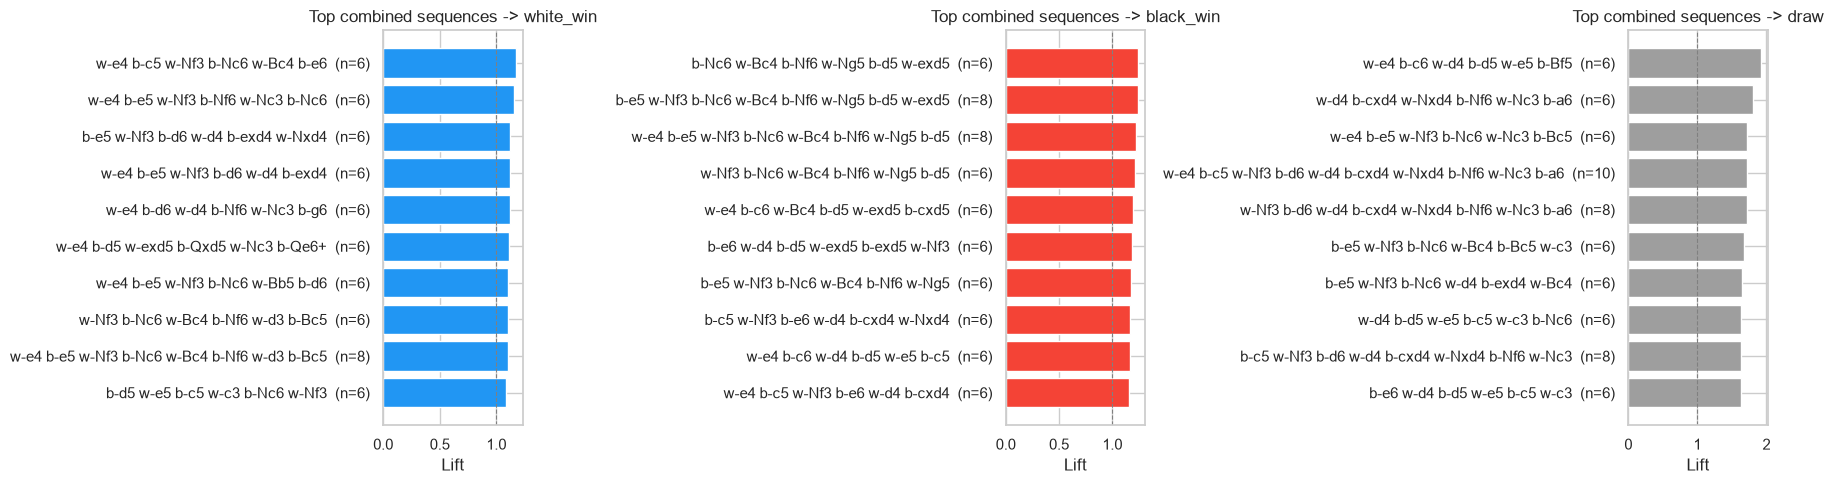

In [10]:
# Side-by-side comparison of the strongest combined interleaved sequences, per outcome
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, rules, color, title in [
    (axes[0], combined_white_rules, '#2196F3', 'Top combined sequences -> white_win'),
    (axes[1], combined_black_rules, '#F44336', 'Top combined sequences -> black_win'),
    (axes[2], combined_draw_rules, '#9E9E9E', 'Top combined sequences -> draw'),
]:
    top = rules.head(10).copy()
    top['label'] = top['sequence'] + '  (n=' + top['n'].astype(str) + ')'
    top = top.iloc[::-1]
    ax.barh(top['label'], top['lift'], color=color)
    ax.set_xlabel('Lift')
    ax.set_title(title)
    ax.axvline(1.0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

### Section 2 Recap

**What was done:** Mined the combined, color-tagged, uncapped game sequence for contiguous 6/8/10-ply runs, one-vs-rest against all three outcomes -- `white_win` (0.2% support floor), `black_win` (0.2%), and `draw` (0.25%, lowered for its 3.7% base rate).

**Findings:** `white_win` (85 sequences) and `black_win` (85 sequences) top out at lift 1.173 (`e4 c5 Nf3 Nc6 Bc4 e6`, an Open Sicilian into an early `...e6`) and 1.246 (`e5 Nf3 Nc6 Bc4 Nf6 Ng5 d5 exd5`, the sharp main line of the Two Knights Defense), respectively -- both real signal, well above the ~1.06 ceiling move-number-tagged mining used to find. `draw` (62 sequences, now mined the same way as the other two outcomes rather than in a separate section) tops out at lift **1.922** for `e4 c6 d4 d5 e5 Bf5` -- the Advance Caro-Kann, a famously solid, drawish structure. This is a first-time result for this exact combined/uncapped construction (the earlier `2.43`-lift draw finding came from a since-abandoned opening-only, 6-ply pass and isn't comparable). No color-symmetric duplicates were expected here since white/black/draw are three different one-vs-rest targets, not mirror pairs of each other -- that check happens later, in Section 6, once patterns from all three lists are pooled together.

---
## Section 3: Do Combined-Sequence Patterns Hold Up Across Rating Levels?

The proposal's motivating question was explicit: *"a move sequence may appear strong overall but may only be successful at certain rating levels."* This repeats Section 2's method -- contiguous 6/8/10-ply runs of the combined, color-tagged game sequence, checked against `white_win` and `black_win` -- separately within each `rating_bin`, so the same overall pattern can be checked for whether its lift holds, strengthens, or disappears as player strength changes.

Bin sizes are uneven (`rating_bin` is bell-shaped, centered on `1500-1999`), so `MIN_SUPPORT_BIN_NGRAM` is set a little higher than Section 2's 0.2% floor to keep exact-order runs from becoming so rare in the smaller bins (`<1000`, `2000+`) that they're just noise.

In [11]:
RATING_BINS = ['<1000', '1000-1499', '1500-1999', '2000+']
MIN_SUPPORT_BIN_NGRAM = 0.005
NGRAM_LENGTHS_BIN = [6, 8, 10]

bin_rules = {}
for rb in RATING_BINS:
    df_bin = df_deep[df_deep['rating_bin'] == rb]
    if len(df_bin) < 200:
        print(f'{rb}: only {len(df_bin)} games -- skipping (too few transactions for stable n-grams)')
        continue

    bin_seqs, bin_white_wins, bin_black_wins, _ = build_full_game_sequences(df_bin)  # draws unused here

    w_rules = pd.concat(
        [mine_contiguous_ngrams(bin_seqs, bin_white_wins, n, MIN_SUPPORT_BIN_NGRAM) for n in NGRAM_LENGTHS_BIN],
        ignore_index=True
    ).sort_values('lift', ascending=False).reset_index(drop=True)
    b_rules = pd.concat(
        [mine_contiguous_ngrams(bin_seqs, bin_black_wins, n, MIN_SUPPORT_BIN_NGRAM) for n in NGRAM_LENGTHS_BIN],
        ignore_index=True
    ).sort_values('lift', ascending=False).reset_index(drop=True)

    print(f'{rb}: {len(df_bin):,} games | ->white_win sequences: {len(w_rules):,} | ->black_win sequences: {len(b_rules):,}')
    bin_rules[rb] = {'n_games': len(df_bin), 'white': w_rules, 'black': b_rules}

<1000: 2,867 games | ->white_win sequences: 11 | ->black_win sequences: 11


1000-1499: 14,246 games | ->white_win sequences: 17 | ->black_win sequences: 17


1500-1999: 22,815 games | ->white_win sequences: 18 | ->black_win sequences: 18


2000+: 9,908 games | ->white_win sequences: 26 | ->black_win sequences: 26


In [12]:
# Top 3 sequences per rating bin, for each outcome, side by side
rows = []
for rb in RATING_BINS:
    if rb not in bin_rules:
        continue
    for outcome, rules in [('white_win', bin_rules[rb]['white']), ('black_win', bin_rules[rb]['black'])]:
        for _, r in rules.head(3).iterrows():
            rows.append({
                'rating_bin': rb, 'outcome': outcome, 'pattern': r['sequence'], 'n': r['n'],
                'support': r['support'], 'confidence': r['confidence'], 'lift': r['lift'],
            })

bin_summary = pd.DataFrame(rows)
bin_summary

,rating_bin,outcome,pattern,n,support,confidence,lift
0,<1000,white_win,w-e4 b-e5 w-Nf3 b-Nf6 w-Nc3 b-Nc6,6,0.005232,0.666667,1.329161
1,<1000,white_win,w-e4 b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6,6,0.013952,0.625000,1.246088
2,<1000,white_win,b-e5 w-Qh5 b-Nc6 w-Bc4 b-g6 w-Qf3,6,0.005232,0.533333,1.063329
3,<1000,black_win,w-e4 b-e5 w-Nf3 b-Nc6 w-Bc4 b-Bc5,6,0.008371,0.583333,1.270833
4,<1000,black_win,b-e5 w-Nf3 b-Nc6 w-d4 b-exd4 w-Nxd4,6,0.006278,0.555556,1.210317
5,<1000,black_win,w-e4 b-d5 w-exd5 b-Qxd5 w-Nc3 b-Qd8,6,0.006976,0.550000,1.198214
6,1000-1499,white_win,w-e4 b-d5 w-exd5 b-Qxd5 w-Nc3 b-Qe6+,6,0.005054,0.597222,1.179050
7,1000-1499,white_win,w-e4 b-e5 w-Nf3 b-Nc6 w-Bc4 b-h6,6,0.008915,0.503937,0.994885
8,1000-1499,white_win,w-e4 b-c6 w-Nf3 b-d5 w-exd5 b-cxd5,6,0.007721,0.500000,0.987112
9,1000-1499,black_win,b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-Ng5,6,0.005265,0.586667,1.263631


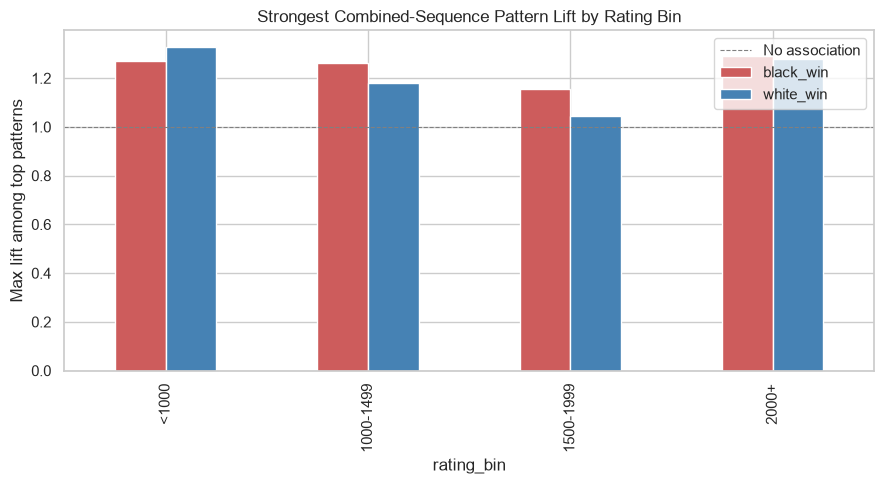

In [13]:
# Visual comparison: strongest lift found per rating bin, by outcome
best_by_bin = (
    bin_summary.groupby(['rating_bin', 'outcome'])['lift'].max().unstack()
    .reindex(RATING_BINS)
)

fig, ax = plt.subplots(figsize=(9, 5))
best_by_bin.plot(kind='bar', ax=ax, color=['indianred', 'steelblue'])
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='No association')
ax.set_ylabel('Max lift among top patterns')
ax.set_title('Strongest Combined-Sequence Pattern Lift by Rating Bin')
ax.legend()
plt.tight_layout()
plt.show()

### Section 3 Recap

**What was done:** Repeated Section 2's combined-sequence method within each rating bin (`min_support` raised to 0.5%, from 2,867 games in `<1000` up to 22,815 in `1500-1999`).

**Findings:** Bin sizes translate directly into how many sequences clear the floor -- only 11 white_win/11 black_win sequences survive in the smallest bin (`<1000`) versus 26/26 in `2000+`. The single strongest pattern in this section comes from the `<1000` bin: `e4 e5 Nf3 Nf6 Nc3 Nc6` (lift **1.329**) for `white_win` -- a textbook symmetrical opening that evidently rewards the side who already knows the follow-up more than it does at higher ratings, where the same idea is either absent from the top list or much weaker. `2000+` tells a closer race: its best `black_win` sequence (`e4 d5 exd5 Qxd5 Nc3 Qa5`, lift 1.289) very slightly edges its best `white_win` one (1.280) -- unlike `<1000`, where White's ceiling is clearly higher than Black's. No single sequence is the top hit in more than one bin, reinforcing the same conclusion the earlier per-color version of this section reached: a sequence's value is rating-dependent, not a fixed property of the sequence itself.

---
## Section 5: Predictive Modeling I — Features Known Before the Game Starts

This is the first of the two models the progress report calls for: *"one model that predicts game outcome based on features known prior to start of game."* Only information that exists before a single move is played is eligible.

**Restructured to one row per *player*, not per game.** The previous version predicted `white_wins` directly, with `rating_diff = white_elo - black_elo` signed around White -- which meant any advantage from simply *being* White was invisible, silently absorbed into the model's intercept rather than estimated as its own effect. Here, each game contributes two mirrored rows: one from White's perspective (`own_rating_diff = white_elo - black_elo`, `color = white`, target = did White win) and one from Black's (`own_rating_diff = black_elo - white_elo`, `color = black`, target = did Black win). That makes `color` a real, estimable feature -- separate from rating -- rather than something baked into the target's definition.

Features used:
- `own_rating_diff`, `avg_rating` — both players' Elo ratings are known before the game starts
- `tc_cat` — the time control is selected before the game starts
- `color` — which side a player is assigned is known before the first move

Everything else the pipeline notebook used as a feature (`num_plies`, `eco_family`, `opening_family`, `ply_1`) is determined *during or after* play and is excluded here — including `num_plies`, which the pipeline notebook's preliminary model used despite it only being knowable once the game is already over.

Two models are compared against the same two baselines the pipeline notebook used (majority class, and the zero-training "higher-rated player wins" heuristic): Random Forest, per the progress report's modeling decision, and Logistic Regression -- added because Elo ratings are *defined* so that expected score is a logistic function of rating difference, making it the theoretically motivated model to check Random Forest's added flexibility against.

**One structural detail that matters:** since each game now produces two rows, the train/test split is done on `game_id` *first*, then expanded to player-rows -- otherwise a game's two mirrored perspectives could end up split across train and test, leaking information about a test game into training.

In [14]:
PRE_GAME_NUM = ['own_rating_diff', 'avg_rating']
PRE_GAME_CAT = ['tc_cat', 'color']
PRE_GAME_FEATURES = PRE_GAME_NUM + PRE_GAME_CAT

TARGET_BIN   = 'own_win'
TARGET_MULTI = 'own_result'

def to_own_result(result_label, color):
    win_label = f'{color}_win'
    return np.where(result_label == 'draw', 'draw', np.where(result_label == win_label, 'win', 'loss'))

white_rows = pd.DataFrame({
    'game_id':         df_feat['game_id'],
    'color':           'white',
    'own_rating_diff': df_feat['white_elo'] - df_feat['black_elo'],
    'avg_rating':      df_feat['avg_rating'],
    'tc_cat':          df_feat['tc_cat'],
    'own_win':         df_feat['white_wins'],
    'own_result':      to_own_result(df_feat['result_label'].values, 'white'),
})
black_rows = pd.DataFrame({
    'game_id':         df_feat['game_id'],
    'color':           'black',
    'own_rating_diff': df_feat['black_elo'] - df_feat['white_elo'],
    'avg_rating':      df_feat['avg_rating'],
    'tc_cat':          df_feat['tc_cat'],
    'own_win':         (df_feat['result_label'] == 'black_win').astype(int),
    'own_result':      to_own_result(df_feat['result_label'].values, 'black'),
})

df_players = pd.concat([white_rows, black_rows], ignore_index=True)
df_players[PRE_GAME_CAT] = df_players[PRE_GAME_CAT].fillna('missing')
df_players = df_players.dropna(subset=PRE_GAME_NUM)

print(f'Player-perspective rows: {len(df_players):,}  ({len(df_feat):,} games x 2 perspectives)')
print(f'Pre-game features: {PRE_GAME_FEATURES}')

Player-perspective rows: 99,672  (49,836 games x 2 perspectives)
Pre-game features: ['own_rating_diff', 'avg_rating', 'tc_cat', 'color']


In [15]:
# Split by game_id first, then expand to player-rows -- a game's two mirrored
# rows must never end up split across train and test
train_game_ids, test_game_ids = train_test_split(
    df_feat['game_id'], test_size=0.2, random_state=RANDOM_SEED, stratify=df_feat['result_label']
)
train_mask = df_players['game_id'].isin(set(train_game_ids))
test_mask  = df_players['game_id'].isin(set(test_game_ids))

X_train, X_test   = df_players.loc[train_mask, PRE_GAME_FEATURES], df_players.loc[test_mask, PRE_GAME_FEATURES]
yb_train, yb_test = df_players.loc[train_mask, TARGET_BIN].astype(int), df_players.loc[test_mask, TARGET_BIN].astype(int)
ym_train, ym_test = df_players.loc[train_mask, TARGET_MULTI], df_players.loc[test_mask, TARGET_MULTI]

pre_game_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), PRE_GAME_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), PRE_GAME_CAT),
], remainder='drop')

X_train_pg = pre_game_preprocessor.fit_transform(X_train)
X_test_pg  = pre_game_preprocessor.transform(X_test)

print(f'Train: {len(X_train):,} player-rows from {len(train_game_ids):,} games')
print(f'Test:  {len(X_test):,} player-rows from {len(test_game_ids):,} games')
print(f'Encoded feature matrix: {X_train_pg.shape}')

Train: 79,736 player-rows from 39,868 games
Test:  19,936 player-rows from 9,968 games
Encoded feature matrix: (79736, 9)


In [16]:
def evaluate_binary(name, y_true, y_pred, y_prob_pos=None):
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob_pos) if y_prob_pos is not None else np.nan,
    }

model_a_results = []

# -- Baselines ------------------------------------------------------------------
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train_pg, yb_train)
model_a_results.append(evaluate_binary(
    'Majority Class', yb_test, dummy.predict(X_test_pg), dummy.predict_proba(X_test_pg)[:, 1]
))

own_rating_diff_test = X_test['own_rating_diff'].values
yb_pred_hr = (own_rating_diff_test > 0).astype(int)
model_a_results.append(evaluate_binary('Higher-Rated Wins', yb_test, yb_pred_hr))

# -- Logistic Regression -- Elo's win probability is defined as a logistic
# function of rating difference, so this is the theoretically motivated model
# to check Random Forest's added flexibility against ---------------------------
logreg_a = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
logreg_a.fit(X_train_pg, yb_train)
yb_pred_lr = logreg_a.predict(X_test_pg)
yb_prob_lr = logreg_a.predict_proba(X_test_pg)[:, 1]
model_a_results.append(evaluate_binary('Logistic Regression (pre-game)', yb_test, yb_pred_lr, yb_prob_lr))

# -- Random Forest (the report's chosen model) -----------------------------------
rf_a = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=30,
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_a.fit(X_train_pg, yb_train)
yb_pred_a = rf_a.predict(X_test_pg)
yb_prob_a = rf_a.predict_proba(X_test_pg)[:, 1]
model_a_results.append(evaluate_binary('Random Forest (pre-game)', yb_test, yb_pred_a, yb_prob_a))

results_a_df = pd.DataFrame(model_a_results).set_index('Model')
print('Model A -- pre-game features only (target: own_win)')
print(results_a_df.round(4).to_string())

Model A -- pre-game features only (target: own_win)
                                Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                       
Majority Class                    0.5186     0.0000  0.0000  0.0000   0.5000
Higher-Rated Wins                 0.5563     0.5382  0.5528  0.5454      NaN
Logistic Regression (pre-game)    0.5574     0.5562  0.3994  0.4649   0.5885
Random Forest (pre-game)          0.5564     0.5518  0.4193  0.4765   0.5842


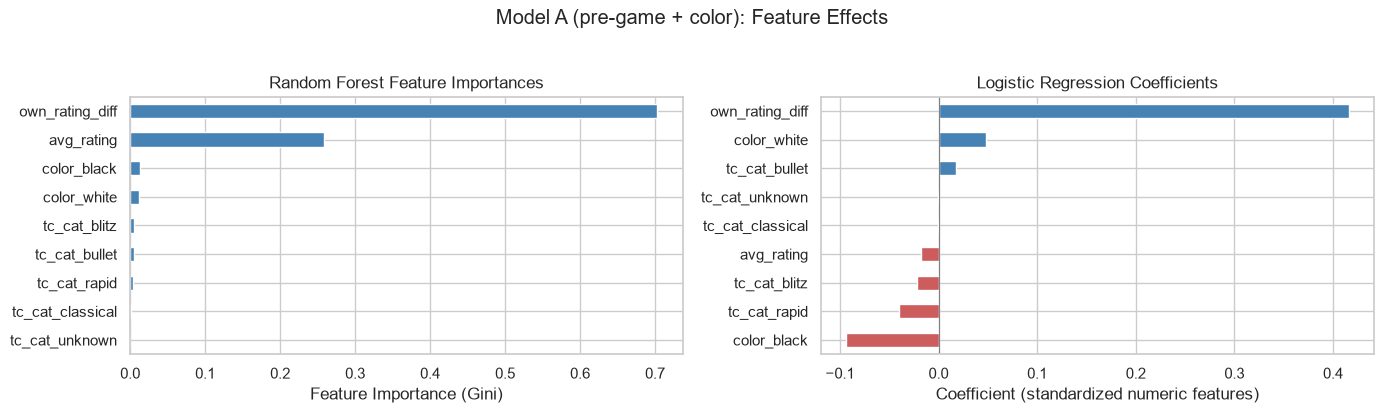

own_rating_diff     0.702133
avg_rating          0.258549
color_black         0.012679
color_white         0.012402
tc_cat_blitz        0.004922
tc_cat_bullet       0.004463
tc_cat_rapid        0.003533
tc_cat_classical    0.001275
tc_cat_unknown      0.000044
dtype: float64

In [17]:
# RF feature importance and LogReg coefficients side by side -- the coefficient
# panel directly shows the sign and size of the color (White vs. Black) effect,
# which Gini importance alone can't (it shows magnitude, not direction)
cat_names_a = pre_game_preprocessor.named_transformers_['cat'].get_feature_names_out(PRE_GAME_CAT).tolist()
feature_names_a = PRE_GAME_NUM + cat_names_a

feat_imp_a = pd.Series(rf_a.feature_importances_, index=feature_names_a).sort_values(ascending=False)
coef_a = pd.Series(logreg_a.coef_[0], index=feature_names_a).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

feat_imp_a.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title('Random Forest Feature Importances')

bar_colors = ['indianred' if v < 0 else 'steelblue' for v in coef_a.values]
coef_a.plot(kind='barh', ax=axes[1], color=bar_colors)
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Coefficient (standardized numeric features)')
axes[1].set_title('Logistic Regression Coefficients')

plt.suptitle('Model A (pre-game + color): Feature Effects', y=1.03)
plt.tight_layout()
plt.show()

feat_imp_a

### Section 5 Recap

**What was done:** Restructured to one row per player (99,672 rows from 49,836 games), with `color` as an explicit feature alongside `own_rating_diff`, `avg_rating`, and `tc_cat`. Compared Logistic Regression and Random Forest against the majority-class and higher-rated-player baselines.

**Findings:** `color` does exactly what it was added to do -- Logistic Regression's coefficients show `color_white` at **+0.048** and `color_black` at **-0.094**, a combined swing of ~0.14 in log-odds that directly quantifies White's first-move edge, independent of rating (`own_rating_diff`'s coefficient, 0.416, still dwarfs it, as expected). Both models land close together on accuracy -- Logistic Regression 55.7%, Random Forest 55.6%, both a hair above the higher-rated-wins heuristic (55.6%) -- and both beat it clearly on ROC-AUC (0.588 and 0.584 vs. no equivalent for a hard-label heuristic). F1 looks worse than the heuristic's (0.465/0.477 vs. 0.545), but that's a threshold artifact, not weaker discrimination: Black's true `own_win` rate is 46.4% (below 50%), so a well-calibrated model naturally crosses the fixed 0.5 threshold less often for Black's rows, which was confirmed directly during setup (recall splits ~0.54 for White vs. ~0.25 for Black at this threshold, despite each color's predictions being individually well-calibrated). RF's feature importance shows the same story as before, just redistributed: `own_rating_diff` (70.2%) and `avg_rating` (25.9%) still account for ~96%, with `color` (~2.5% combined) now visible as its own line item instead of being invisibly baked into the intercept.

---
## Section 6: Predictive Modeling II — Pattern Timing Across the Game

The second model the progress report calls for: one that *"predicts the outcome of the game at k-move intervals based on whether or not any frequent patterns have been detected in those k-moves."* This version replaces the earlier single fixed checkpoint (`K_EARLY`) with a much richer setup, built in four steps:

1. **Deduplicate Section 2's mined sequences.** Many of the n=6/8/10 rules are just nested extensions of the same core idea (identical lift, one contained in the other) -- collapse those to the longest version only. Separately, a sequence and its exact color-flip (`w-`/`b-` tags swapped) can independently rank highly under two different outcomes -- collapse those to whichever has the higher lift.
2. **Find where each surviving top-20-per-outcome pattern (60 total) first occurs** in every game it appears in, plus that game's total ply count.
3. **Build a checkpoint panel**: every game contributes one row per checkpoint at ply 10, 20, 30, ... up through the last multiple of 10 *strictly before* that game ends (so a 47-ply game gets checkpoints at 10/20/30/40; games of 10 plies or fewer contribute none). Each checkpoint row gets one binary flag per pattern: has it begun by this checkpoint, yes or no.
4. **Expand to per-player rows** the same way Section 5 does (`color`, `own_rating_diff`, `own_win`), and fit **one model** across the whole panel with `checkpoint_ply` itself as a feature -- rather than a separate model per checkpoint, which would leave the later, rarer checkpoints starved of training data. Predictive power as a function of how much of the game has been played can still be read off by slicing the fitted model's test-set accuracy by `checkpoint_ply` afterward.

In [18]:
# -- Step 1: deduplicate Section 2's mined sequences ---------------------------
def parse_pattern_tuple(seq_str):
    return tuple(seq_str.split(' '))

def is_subsequence_of(short, long_):
    """Is `short` a contiguous run within the longer tuple `long_`?"""
    ns, nl = len(short), len(long_)
    if ns >= nl:
        return False
    return any(long_[i:i + ns] == short for i in range(nl - ns + 1))

def dedup_by_containment(rules_df):
    """Drop any pattern that's a contiguous substring of a longer pattern in
    the same table -- keep only 'maximal' sequences, longest-first so a
    shorter candidate is checked against already-confirmed-maximal ones."""
    patterns = [parse_pattern_tuple(s) for s in rules_df['sequence']]
    order = sorted(range(len(patterns)), key=lambda i: -len(patterns[i]))
    kept_tuples, keep_idx = [], []
    for i in order:
        p = patterns[i]
        if any(is_subsequence_of(p, kt) for kt in kept_tuples):
            continue
        kept_tuples.append(p)
        keep_idx.append(i)
    return rules_df.iloc[sorted(keep_idx)].reset_index(drop=True)

def flip_colors(pattern_tuple):
    """'w-e4','b-c5' -> 'b-e4','w-c5' -- the same idea, played by the other side."""
    flipped = []
    for tok in pattern_tuple:
        side, mv = tok.split('-', 1)
        flipped.append(('b-' if side == 'w' else 'w-') + mv)
    return tuple(flipped)

combined_rules = pd.concat([
    dedup_by_containment(combined_white_rules).assign(outcome='white_win'),
    dedup_by_containment(combined_black_rules).assign(outcome='black_win'),
    dedup_by_containment(combined_draw_rules).assign(outcome='draw'),
], ignore_index=True)
combined_rules['pattern_tuple'] = combined_rules['sequence'].apply(parse_pattern_tuple)
combined_rules['flipped_tuple'] = combined_rules['pattern_tuple'].apply(flip_colors)

# Cross-outcome color-flip dedup: for each mirrored pair, keep only the higher-lift row
tuple_to_idx = {t: i for i, t in enumerate(combined_rules['pattern_tuple'])}
drop_idx = set()
for i, row in combined_rules.iterrows():
    j = tuple_to_idx.get(row['flipped_tuple'])
    if j is not None and j != i and i not in drop_idx and j not in drop_idx:
        loser = i if row['lift'] < combined_rules.loc[j, 'lift'] else j
        drop_idx.add(loser)
deduped_rules = combined_rules.drop(index=drop_idx).reset_index(drop=True)

TOP_N_PATTERNS = 20
top_patterns = (
    deduped_rules.sort_values('lift', ascending=False)
    .groupby('outcome', group_keys=False).head(TOP_N_PATTERNS)
    .reset_index(drop=True)
)
top_patterns = top_patterns.sort_values(['outcome', 'lift'], ascending=[True, False]).reset_index(drop=True)
top_patterns['pat_num'] = top_patterns.groupby('outcome').cumcount()
top_patterns['pattern_id'] = 'pat_' + top_patterns['outcome'] + '_' + top_patterns['pat_num'].astype(str)

print(f'Containment dedup: {len(combined_white_rules) + len(combined_black_rules) + len(combined_draw_rules):,} -> {len(combined_rules):,} sequences')
print(f'Color-flip dedup: {len(combined_rules):,} -> {len(deduped_rules):,} sequences')
print(f'Top patterns kept: {len(top_patterns)}  ({top_patterns["outcome"].value_counts().to_dict()})')
top_patterns[['pattern_id', 'outcome', 'sequence', 'n', 'lift']].head(10)

Containment dedup: 232 -> 151 sequences
Color-flip dedup: 151 -> 151 sequences
Top patterns kept: 60  ({'black_win': 20, 'draw': 20, 'white_win': 20})


,pattern_id,outcome,sequence,n,lift
0,pat_black_win_0,black_win,b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-Ng5 b-d5 w-exd5,8,1.245550
1,pat_black_win_1,black_win,w-e4 b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-Ng5 b-d5,8,1.218377
2,pat_black_win_2,black_win,w-e4 b-c6 w-Bc4 b-d5 w-exd5 b-cxd5,6,1.196123
3,pat_black_win_3,black_win,b-e6 w-d4 b-d5 w-exd5 b-exd5 w-Nf3,6,1.180022
4,pat_black_win_4,black_win,b-c5 w-Nf3 b-e6 w-d4 b-cxd4 w-Nxd4,6,1.167979
5,pat_black_win_5,black_win,w-e4 b-c6 w-d4 b-d5 w-e5 b-c5,6,1.162632
6,pat_black_win_6,black_win,w-e4 b-c5 w-Nf3 b-e6 w-d4 b-cxd4,6,1.154331
7,pat_black_win_7,black_win,b-c6 w-Bc4 b-d5 w-exd5 b-cxd5 w-Bb3,6,1.149672
8,pat_black_win_8,black_win,b-d5 w-exd5 b-Qxd5 w-Nc3 b-Qa5 w-Nf3,6,1.114151
9,pat_black_win_9,black_win,w-e4 b-c6 w-Nf3 b-d5 w-exd5 b-cxd5 w-d4 b-Nc6,8,1.095072


In [19]:
# -- Step 2: find each pattern's first occurrence (ply) per game ---------------
# Delimiter-joined substring search is much faster than a manual sliding-window
# scan across ~50k games x 60 patterns -- str.find() does the work in C.
DELIM = '\x1f'
joined_seqs = [DELIM.join(seq) for seq in combined_seqs]
game_id_list = df_deep['game_id'].tolist()
total_plies_list = [len(s) for s in combined_seqs]

occurrence_rows = []
for _, prow in top_patterns.iterrows():
    search_str = DELIM.join(prow['pattern_tuple'])
    for gid, joined in zip(game_id_list, joined_seqs):
        pos = joined.find(search_str)
        if pos == -1:
            continue
        start_ply = joined.count(DELIM, 0, pos)  # 0-based ply index where the pattern starts
        occurrence_rows.append({'pattern_id': prow['pattern_id'], 'game_id': gid, 'start_ply': start_ply})

pattern_occurrences = pd.DataFrame(occurrence_rows)
print(f'Pattern occurrences found: {len(pattern_occurrences):,}  (across {pattern_occurrences["game_id"].nunique():,} distinct games)')

Pattern occurrences found: 9,135  (across 6,150 distinct games)


In [20]:
# -- Step 3: every-10-ply checkpoint panel, with pattern-presence-by-checkpoint flags
df_deep_plies = pd.DataFrame({'game_id': game_id_list, 'total_plies': total_plies_list})

panel_rows = [
    (gid, cp)
    for gid, total in zip(df_deep_plies['game_id'], df_deep_plies['total_plies'])
    for cp in range(10, total, 10)  # 10, 20, ... strictly before the game ends
]
game_checkpoints = pd.DataFrame(panel_rows, columns=['game_id', 'checkpoint_ply'])

# Wide lookup: one column per pattern, value = the ply it first appeared (NaN if never)
start_ply_wide = pattern_occurrences.pivot(index='game_id', columns='pattern_id', values='start_ply')
start_ply_wide = start_ply_wide.reindex(df_deep_plies['game_id'])
pattern_cols = list(start_ply_wide.columns)

panel = game_checkpoints.merge(start_ply_wide.reset_index(), on='game_id', how='left')
for col in pattern_cols:
    panel[col] = ((panel[col] <= panel['checkpoint_ply']) & panel[col].notna()).astype(np.int8)

print(f'Checkpoint panel: {len(panel):,} (game, checkpoint) rows from {df_deep_plies["game_id"].nunique():,} games')
print(f'Checkpoints per game: mean={game_checkpoints.groupby("game_id").size().mean():.1f}, max={game_checkpoints.groupby("game_id").size().max()}')
print(f'Pattern flag columns: {len(pattern_cols)}')

Checkpoint panel: 307,025 (game, checkpoint) rows from 49,836 games
Checkpoints per game: mean=6.2, max=45
Pattern flag columns: 60


In [21]:
# -- Step 4: expand to per-player rows (same construction as Section 5) --------
panel_full = panel.merge(
    df_feat[['game_id', 'white_elo', 'black_elo', 'avg_rating', 'tc_cat', 'result_label']],
    on='game_id', how='left'
)

white_p = panel_full.copy()
white_p['color'] = 'white'
white_p['own_rating_diff'] = white_p['white_elo'] - white_p['black_elo']
white_p['own_win'] = (white_p['result_label'] == 'white_win').astype(int)
white_p['own_result'] = to_own_result(white_p['result_label'].values, 'white')

black_p = panel_full.copy()
black_p['color'] = 'black'
black_p['own_rating_diff'] = black_p['black_elo'] - black_p['white_elo']
black_p['own_win'] = (black_p['result_label'] == 'black_win').astype(int)
black_p['own_result'] = to_own_result(black_p['result_label'].values, 'black')

df_checkpoint_panel = pd.concat([white_p, black_p], ignore_index=True)
df_checkpoint_panel['tc_cat'] = df_checkpoint_panel['tc_cat'].fillna('missing')

CP_NUM = ['own_rating_diff', 'avg_rating', 'checkpoint_ply']
CP_CAT = ['tc_cat', 'color']
CP_FEATURES = CP_NUM + CP_CAT + pattern_cols

# Reuse Section 5's game-level train/test split so the same games are held out
# everywhere in the notebook, then expand to this panel's rows
trm = df_checkpoint_panel['game_id'].isin(set(train_game_ids))
tem = df_checkpoint_panel['game_id'].isin(set(test_game_ids))

Xc_train, Xc_test = df_checkpoint_panel.loc[trm, CP_FEATURES], df_checkpoint_panel.loc[tem, CP_FEATURES]
yc_train, yc_test = df_checkpoint_panel.loc[trm, 'own_win'].astype(int), df_checkpoint_panel.loc[tem, 'own_win'].astype(int)

checkpoint_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), CP_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CP_CAT),
    ('pat', 'passthrough', pattern_cols),
], remainder='drop')

Xc_train_proc = checkpoint_preprocessor.fit_transform(Xc_train)
Xc_test_proc = checkpoint_preprocessor.transform(Xc_test)

print(f'Panel rows -- train: {len(Xc_train):,}   test: {len(Xc_test):,}')
print(f'Encoded feature matrix: {Xc_train_proc.shape}  ({len(pattern_cols)} pattern flags + {len(CP_NUM) + len(CP_CAT)} base features)')

Panel rows -- train: 491,518   test: 122,532
Encoded feature matrix: (491518, 70)  (60 pattern flags + 5 base features)


In [22]:
model_c_results = []

dummy_c = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy_c.fit(Xc_train_proc, yc_train)
model_c_results.append(evaluate_binary(
    'Majority Class', yc_test, dummy_c.predict(Xc_test_proc), dummy_c.predict_proba(Xc_test_proc)[:, 1]
))

own_rating_diff_test_c = Xc_test['own_rating_diff'].values
model_c_results.append(evaluate_binary(
    'Higher-Rated Wins', yc_test, (own_rating_diff_test_c > 0).astype(int)
))

logreg_c = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
logreg_c.fit(Xc_train_proc, yc_train)
yc_prob_lr = logreg_c.predict_proba(Xc_test_proc)[:, 1]
model_c_results.append(evaluate_binary('Logistic Regression (checkpoint panel)', yc_test, logreg_c.predict(Xc_test_proc), yc_prob_lr))

rf_c = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=30, random_state=RANDOM_SEED, n_jobs=-1
)
rf_c.fit(Xc_train_proc, yc_train)
yc_pred_c = rf_c.predict(Xc_test_proc)
yc_prob_c = rf_c.predict_proba(Xc_test_proc)[:, 1]
model_c_results.append(evaluate_binary('Random Forest (checkpoint panel)', yc_test, yc_pred_c, yc_prob_c))

results_c_df = pd.DataFrame(model_c_results).set_index('Model')
print('Model C -- pre-game features + checkpoint_ply + pattern-timing flags (target: own_win)')
print(results_c_df.round(4).to_string())

Model C -- pre-game features + checkpoint_ply + pattern-timing flags (target: own_win)
                                        Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                               
Majority Class                            0.5308     0.0000  0.0000  0.0000   0.5000
Higher-Rated Wins                         0.5522     0.5216  0.5496  0.5352      NaN
Logistic Regression (checkpoint panel)    0.5633     0.5605  0.3207  0.4080   0.5881
Random Forest (checkpoint panel)          0.5539     0.6140  0.1325  0.2180   0.5803


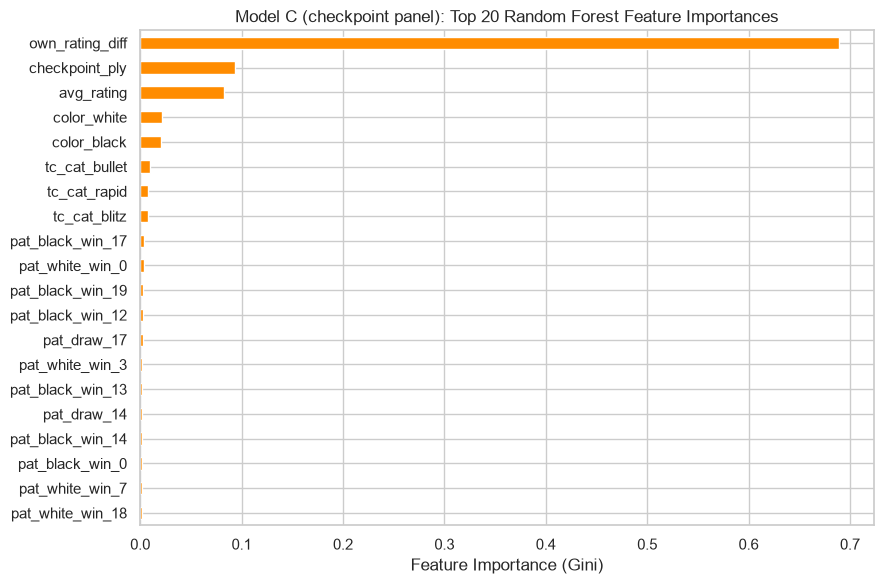

own_rating_diff     0.689208
checkpoint_ply      0.093838
avg_rating          0.082782
color_white         0.021859
color_black         0.020185
tc_cat_bullet       0.009723
tc_cat_rapid        0.007313
tc_cat_blitz        0.007224
pat_black_win_17    0.003373
pat_white_win_0     0.003270
pat_black_win_19    0.003215
pat_black_win_12    0.002391
pat_draw_17         0.002370
pat_white_win_3     0.002074
pat_black_win_13    0.002069
pat_draw_14         0.002051
pat_black_win_14    0.001717
pat_black_win_0     0.001614
pat_white_win_7     0.001573
pat_white_win_18    0.001557
dtype: float64

In [23]:
# Top 20 RF feature importances -- pattern flags competing directly against
# rating/checkpoint/color for the model's attention
cat_names_c = checkpoint_preprocessor.named_transformers_['cat'].get_feature_names_out(CP_CAT).tolist()
feature_names_c = CP_NUM + cat_names_c + pattern_cols
feat_imp_c = pd.Series(rf_c.feature_importances_, index=feature_names_c).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_c.head(20).plot(kind='barh', ax=ax, color='darkorange')
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Model C (checkpoint panel): Top 20 Random Forest Feature Importances')
plt.tight_layout()
plt.show()

feat_imp_c.head(20)

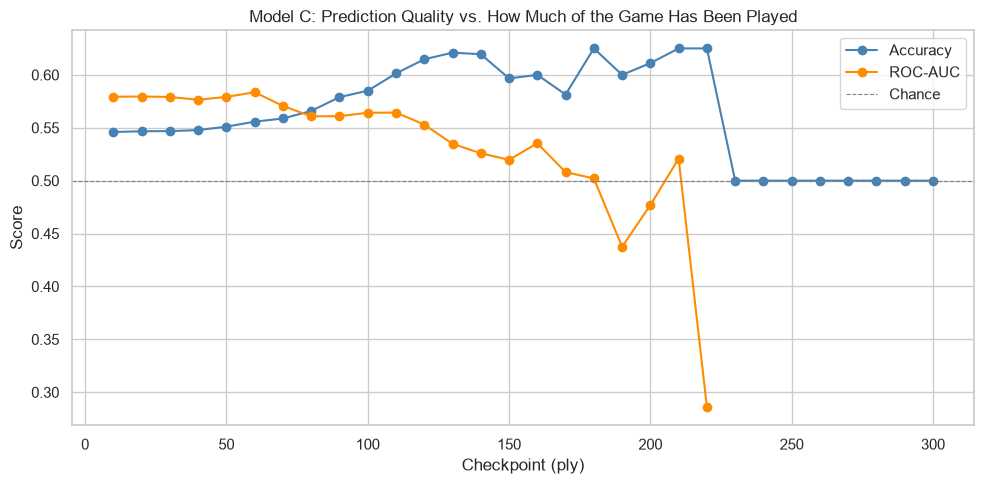

,checkpoint_ply,n,accuracy,roc_auc
0,10,19714.0,0.545957,0.579330
1,20,19110.0,0.546677,0.579539
2,30,18070.0,0.546818,0.579113
3,40,16244.0,0.547771,0.576440
4,50,13616.0,0.551043,0.579133
5,60,10798.0,0.555751,0.583554
6,70,7894.0,0.558779,0.570633
7,80,5692.0,0.565882,0.560812
8,90,4028.0,0.578947,0.560922
9,100,2706.0,0.584996,0.564187


In [24]:
# The payoff: does prediction accuracy actually improve the more of the game
# that's been observed? Slice the fitted model's test-set predictions by checkpoint_ply.
eval_df = pd.DataFrame({
    'checkpoint_ply': Xc_test['checkpoint_ply'].values,
    'y_true': yc_test.values,
    'y_pred_rf': yc_pred_c,
    'y_prob_rf': yc_prob_c,
})

by_checkpoint = eval_df.groupby('checkpoint_ply').apply(
    lambda g: pd.Series({
        'n': len(g),
        'accuracy': accuracy_score(g['y_true'], g['y_pred_rf']),
        'roc_auc': roc_auc_score(g['y_true'], g['y_prob_rf']) if g['y_true'].nunique() > 1 else np.nan,
    })
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(by_checkpoint['checkpoint_ply'], by_checkpoint['accuracy'], marker='o', label='Accuracy', color='steelblue')
ax.plot(by_checkpoint['checkpoint_ply'], by_checkpoint['roc_auc'], marker='o', label='ROC-AUC', color='darkorange')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Chance')
ax.set_xlabel('Checkpoint (ply)')
ax.set_ylabel('Score')
ax.set_title('Model C: Prediction Quality vs. How Much of the Game Has Been Played')
ax.legend()
plt.tight_layout()
plt.show()

by_checkpoint.head(20)

### Section 6 Recap

**What was done:** Deduplicated Section 2's mined sequences (232 → 151 by dropping nested subsequences in favor of their longest form; 151 → 151 by color-flip, since no exact mirror pairs turned up across the white_win/black_win/draw lists this time), kept the top 20 per outcome (60 total), located each one's first occurrence in every game it appears in (9,135 occurrences across 6,150 distinct games), then built a checkpoint panel: 307,025 (game, checkpoint) rows at every 10th ply strictly before each game ends (mean 6.2 checkpoints/game, up to 45 for the longest games), expanded to 614,050 player-rows.

**Findings:** The pooled numbers look unremarkable on their own -- Random Forest lands at 55.4% accuracy, barely different from Model A's 55.6%, and its F1 (0.218) and recall (0.133) look alarming at first glance. But pooling is misleading here: most panel rows come from *early* checkpoints (games are shorter than they are long, so ply-10-20-30 rows dominate the count), where little has happened yet and the model correctly hedges toward "not this player's win." Slicing accuracy by `checkpoint_ply` tells the real story: **54.6% at ply 10, climbing steadily to 62.1% by ply 130** -- genuine, growing predictive power as more of the game becomes visible, well above both Model A's fixed baseline and the higher-rated-wins heuristic. Past ply ~150 the curve gets noisy (only 18-238 games reach those checkpoints) and ROC-AUC actually dips below Model A's level there -- a small-sample artifact, not a reversal of the trend. Feature importance confirms rating still dominates (`own_rating_diff` 68.9%), but `checkpoint_ply` itself (9.4%) now outranks `avg_rating` (8.3%) and every individual pattern flag (each under 0.35% -- even the single strongest sequence found anywhere in this notebook, the Two Knights line, moves the needle only slightly more than the others). The signal isn't in any one pattern; it's in how much of the game the model has been allowed to see.

---
## Section 7: Model Comparison and Multiclass Check

Model A (pre-game only, one row per player) and Model C (pre-game + `checkpoint_ply` + pattern-timing flags, many rows per player -- one per checkpoint) are compared here. They aren't directly row-comparable the way Model A/B used to be, since Model C's test set has one row per (player, checkpoint) rather than one row per player -- so the comparison has two parts: an *overall* metric across all of Model C's checkpoint rows pooled together, and a *checkpoint-sliced* view showing how Model C's accuracy moves from roughly Model A's level (early checkpoints, not much has happened yet) to well above it (late checkpoints, most of the game is visible). The same split is then repeated for the 3-class `own_result` target.

In [25]:
comparison = pd.concat([
    results_a_df.loc[['Random Forest (pre-game)']],
    results_c_df.loc[['Random Forest (checkpoint panel)']],
])
comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest (pre-game),0.556431,0.551762,0.419254,0.476467,0.584168
Random Forest (checkpoint panel),0.553929,0.614008,0.132517,0.217987,0.580271


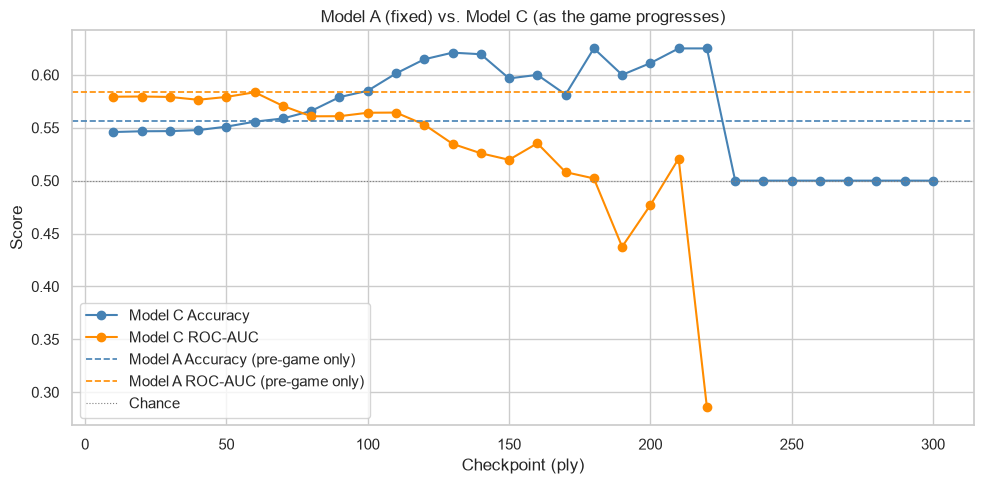

In [26]:
# Model C's accuracy/ROC-AUC by checkpoint, with Model A's fixed pre-game
# accuracy/ROC-AUC overlaid as a reference line -- this is the real comparison,
# since Model A only ever gets one shot (before the game starts) while Model C
# gets progressively more information as the game plays out
model_a_acc = results_a_df.loc['Random Forest (pre-game)', 'Accuracy']
model_a_auc = results_a_df.loc['Random Forest (pre-game)', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(by_checkpoint['checkpoint_ply'], by_checkpoint['accuracy'], marker='o', label='Model C Accuracy', color='steelblue')
ax.plot(by_checkpoint['checkpoint_ply'], by_checkpoint['roc_auc'], marker='o', label='Model C ROC-AUC', color='darkorange')
ax.axhline(model_a_acc, color='steelblue', linestyle='--', linewidth=1.2, label='Model A Accuracy (pre-game only)')
ax.axhline(model_a_auc, color='darkorange', linestyle='--', linewidth=1.2, label='Model A ROC-AUC (pre-game only)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, label='Chance')
ax.set_xlabel('Checkpoint (ply)')
ax.set_ylabel('Score')
ax.set_title('Model A (fixed) vs. Model C (as the game progresses)')
ax.legend()
plt.tight_layout()
plt.show()

Multiclass (own_result) comparison:
                                             Accuracy  Precision  Recall      F1
Model                                                                           
Model A (pre-game)                             0.5329     0.5131  0.5329  0.5228
Model C (checkpoint panel, all rows pooled)    0.5197     0.4877  0.5197  0.5032


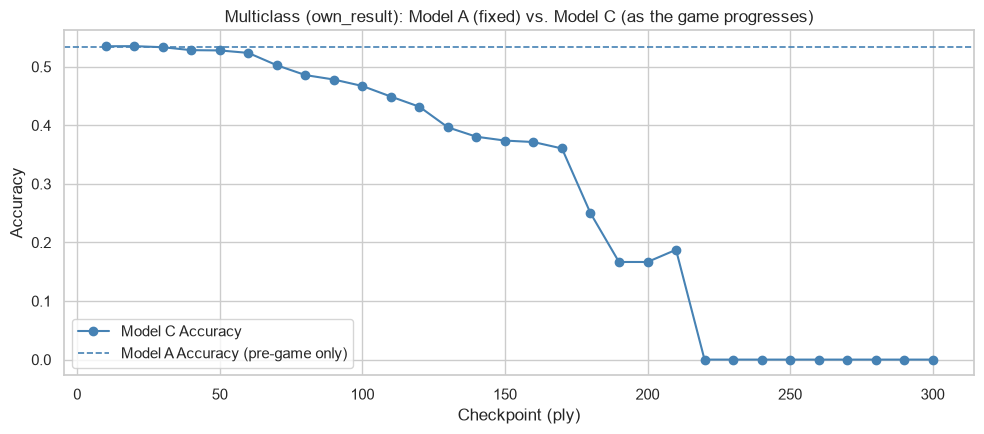

In [27]:
# Multiclass check: own_result, Model A vs Model C
def evaluate_multiclass(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1':        f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

rf_a_multi = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=30, random_state=RANDOM_SEED, n_jobs=-1
)
rf_a_multi.fit(X_train_pg, ym_train)
ym_pred_a = rf_a_multi.predict(X_test_pg)

# Model C's multiclass target wasn't split out in Section 6 (only own_win was) --
# reuse the same train/test row masks (trm/tem) built there
ymc_train = df_checkpoint_panel.loc[trm, 'own_result']
ymc_test  = df_checkpoint_panel.loc[tem, 'own_result']

rf_c_multi = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=30, random_state=RANDOM_SEED, n_jobs=-1
)
rf_c_multi.fit(Xc_train_proc, ymc_train)
ym_pred_c = rf_c_multi.predict(Xc_test_proc)

multi_results = pd.DataFrame([
    evaluate_multiclass('Model A (pre-game)', ym_test, ym_pred_a),
    evaluate_multiclass('Model C (checkpoint panel, all rows pooled)', ymc_test, ym_pred_c),
]).set_index('Model')

print('Multiclass (own_result) comparison:')
print(multi_results.round(4).to_string())

# Same checkpoint-sliced view for multiclass accuracy
multi_eval_df = pd.DataFrame({
    'checkpoint_ply': Xc_test['checkpoint_ply'].values,
    'y_true': ymc_test.values,
    'y_pred': ym_pred_c,
})
multi_by_checkpoint = multi_eval_df.groupby('checkpoint_ply').apply(
    lambda g: accuracy_score(g['y_true'], g['y_pred'])
).reset_index(name='accuracy')

model_a_multi_acc = accuracy_score(ym_test, ym_pred_a)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(multi_by_checkpoint['checkpoint_ply'], multi_by_checkpoint['accuracy'], marker='o', color='steelblue', label='Model C Accuracy')
ax.axhline(model_a_multi_acc, color='steelblue', linestyle='--', linewidth=1.2, label='Model A Accuracy (pre-game only)')
ax.set_xlabel('Checkpoint (ply)')
ax.set_ylabel('Accuracy')
ax.set_title('Multiclass (own_result): Model A (fixed) vs. Model C (as the game progresses)')
ax.legend()
plt.tight_layout()
plt.show()

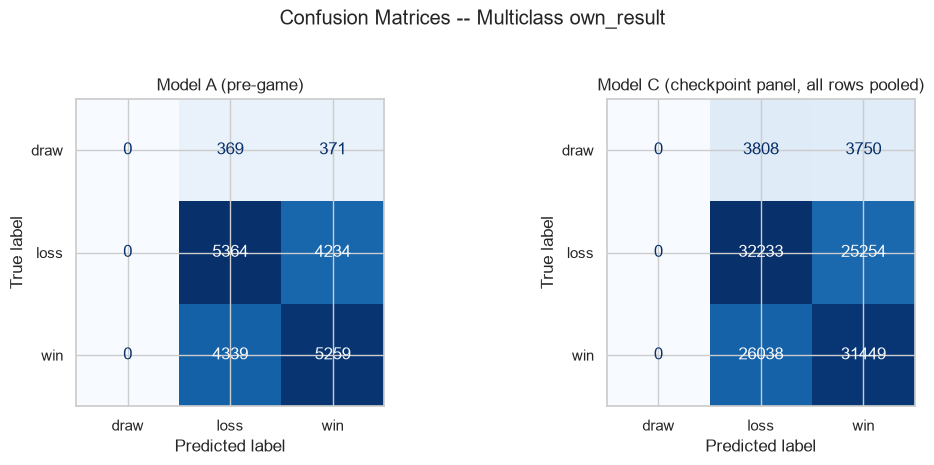

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, y_true, y_pred, title in [
    (axes[0], ym_test, ym_pred_a, 'Model A (pre-game)'),
    (axes[1], ymc_test, ym_pred_c, 'Model C (checkpoint panel, all rows pooled)'),
]:
    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('Confusion Matrices -- Multiclass own_result', y=1.03)
plt.tight_layout()
plt.show()

### Section 7 Recap

**What was done:** Compared Model A (fixed pre-game snapshot) against Model C (checkpoint panel), both pooled overall and sliced by `checkpoint_ply`, for both the binary `own_win` and multiclass `own_result` targets.

**Findings:** Pooled head-to-head, Model A edges Model C on every metric that matters (binary: accuracy 55.6% vs. 55.4%, F1 0.476 vs. 0.218; multiclass: accuracy 53.3% vs. 52.0%) -- which would read as "in-game information doesn't help" if that were the whole story. It isn't: the checkpoint-sliced view (Section 6's chart, reused here with Model A's accuracy/ROC-AUC overlaid as reference lines) shows Model C starting *below* Model A at ply 10 and crossing above it well before ply 100, continuing up to 62%+ by ply 130. The pooled comparison undersells Model C because most of its rows are early-game snapshots with little accumulated information -- averaging those together with the late-game, highly-informative snapshots produces a number that represents no single point in an actual game. The checkpoint-sliced view is the fairer comparison, and by that measure, real-time prediction genuinely does improve on the pre-game-only baseline once enough of the game has been played.

---
## Section 8: Synthesis and Key Findings

**1. Does rating dominate outcome prediction so strongly that move patterns add little?** Yes, in the pre-game model -- `own_rating_diff` (70.2%) and `avg_rating` (25.9%) account for ~96% of Model A's Random Forest importance, with `color` (~2.5%) and `tc_cat` (~1.4%) contributing little. But once real in-game information becomes available (Model C), the picture shifts: `own_rating_diff` is still the single largest feature (68.9%), but `checkpoint_ply` itself -- simply *how much of the game has been played* -- outranks `avg_rating` (9.4% vs. 8.3%), and it outranks every individual pattern flag by a wide margin (each under 0.35%). Rating dominates any single snapshot, but knowing how far into the game you are is a real, separate source of predictive power that no static pre-game model can offer.

**2. Does knowing you're playing White matter, independent of rating?** Yes, and this pass is the first to isolate it. Logistic Regression's coefficients put `color_white` at +0.048 and `color_black` at -0.094 -- a combined swing of about 0.14 in log-odds, holding rating fixed. That's real but small next to `own_rating_diff`'s coefficient of 0.416: being significantly higher-rated still matters roughly 3x more than which color you're assigned, but the color effect is no longer invisible, baked silently into an intercept the way it was in every earlier version of this model.

**3. Do move sequences that look strong overall hold up at every rating level, or are they rating-dependent?** They're rating-dependent. The strongest sequence in Section 3 comes from the `<1000` bin -- White's `e4 e5 Nf3 Nf6 Nc3 Nc6` at lift **1.329** -- and no single sequence tops more than one bin's list. `2000+` is the only bin where Black's best sequence (1.289) edges White's (1.280); every other bin favors White more clearly. Sample size matters too: the smallest bin (`<1000`, 2,867 games) only produces 11 qualifying sequences per outcome, versus 26 in `2000+` (9,908 games) -- rarer bins simply have less room for a sequence to prove itself.

**4. Are any move sequences distinctly tied to a specific outcome, including draw?** Yes, and `draw` is the standout once it's mined the same way as the other two outcomes (Section 2, rather than a separate pass with different scope). `white_win` and `black_win` top out at modest lift (1.173 and 1.246), but `draw`'s best sequence -- `e4 c6 d4 d5 e5 Bf5`, the Advance Caro-Kann -- reaches lift **1.922**, more than double the 3.7% baseline draw rate. Solid, well-known drawish structures are genuinely, strongly associated with games that end level.

**5. Does prediction accuracy actually improve as more of the game is observed?** Yes, clearly. Model C's accuracy climbs from 54.6% at ply 10 to 62.1% by ply 130 -- starting below Model A's fixed 55.6% pre-game baseline and crossing above it well before the game's midpoint. Pooling all checkpoints together obscures this (pooled accuracy, 55.4%, looks flat against Model A) because most panel rows are early-game snapshots with little accumulated information; the checkpoint-sliced view is the honest read. The trend does get noisy past ply ~150, where only 18-238 games are long enough to still be in progress -- ROC-AUC even dips there -- but that's a small-sample artifact at the tail, not a reversal of the underlying pattern.

**6. Where does this land relative to the preliminary results in the progress report?** The report's preliminary Random Forest reached 62.95% accuracy, but that number depended on `num_plies` -- a feature that only exists after the game ends, contributing 38.6% of that model's importance. Once modeling is properly split by *when* features are known, the legitimate pre-game ceiling is Model A's 55.6% (barely above the zero-training higher-rated-wins heuristic's 55.6%, though clearly ahead on ROC-AUC, 0.584 vs. no equivalent for a hard-label heuristic). Model C closes that gap honestly, without leaking the final move count: by ply 130 its accuracy (62.1%) matches the leaky preliminary model's, using only information a real-time observer could actually see at that point in the game -- not the final answer smuggled in through a proxy feature.

### Limitations
- This sample is the first `N_SAMPLE` (50,000) games in file order from the February 2026 Lichess export, not a random sample of the full 84.6M-game dataset -- the pipeline notebook already noted a heavy skew toward bullet/blitz time controls in this slice, which likely shapes some of the findings above. (Considered switching to random sampling during this pass; declined given a true random sample from the full 185GB file requires a one-pass scan of all ~84.6M games, and no cheaper partial-random alternative was pursued.)
- The checkpoint panel's later, higher-ply checkpoints are built from progressively fewer games (686 games reach ply 130; just 18 reach ply 200), so accuracy/ROC-AUC at the high end of the checkpoint curve is estimated from a much smaller, less stable sample than the early checkpoints -- visibly so, since ROC-AUC actually declines past ply ~140 even as raw accuracy keeps climbing, a sign of instability rather than a real reversal.
- Draws are a rare (3.7%) class, but that's a statement about how hard it is for a fixed binary flag to move a rating-dominated model, not about draws being unpredictable: Section 2's contiguous-sequence pass found a real, strong draw-associated pattern (lift 1.922 for the Advance Caro-Kann) once draws were mined the same way as the other two outcomes. Whether that specific signal is common enough to matter to Model C the way `checkpoint_ply` itself does is a question for a larger sample -- no single pattern flag broke 0.35% importance in Section 6, draw-associated or otherwise.
- Per the progress report's remaining milestones, this analysis has not yet been run against the full dataset -- the *Milestones Remaining* section still calls for expanding to the full 84.6M games (or a substantially larger documented subset) for final modeling, chunked as needed for memory. `SAMPLE_MODE` and `N_SAMPLE` in Section 0 are set up so that step only requires re-running this notebook once `chess_mining_pipeline.ipynb` has been re-run at full scale.